In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import re
import ast
import json
import os

# Translation Table

NB: HERE WE WORK ONLY WITH ARTICLES WHICH HAVE FULL-TEXT -> CAN IMPACT THE NUMBER OF REPORTED ENTITIES. IF THEY HAD NO STUDIES WITH ANNOTATIONS, THEY ARE EXCLUDED

In [153]:
translation_table = pd.read_csv("/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/10_use_case_disease_focus/out/translation_table_drug_disease.csv") # from Translation_02_Drug_Disease

In [154]:
translation_table.shape

(13570, 29)

In [155]:
13570+2253

15823

### NB: current implementation does not add FDA only rows!!! would be + 2253 for translated -> 15823 as in table 3 (see Translation 2)

In [156]:
keep_linked_only = False
if keep_linked_only:
    # Filter to keep rows where both IDs are NOT -1
    translation_table = translation_table[
        (translation_table['merged_mondo_termid'] != "-1") & 
        (translation_table['merged_umls_termid'] != "-1")
    ]
    
    # Reset index for a clean dataframe
    translation_table = translation_table.reset_index(drop=True)

In [157]:
translation_table.shape

(13570, 29)

In [158]:
n_diseases = translation_table["merged_mondo_label"].nunique()
n_drugs = translation_table["merged_umls_label"].nunique()

print("\n=== Entity coverage summary ===")
print(f"Total unique diseases: {n_diseases:,}")
print(f"Total unique drugs: {n_drugs:,}")



=== Entity coverage summary ===
Total unique diseases: 1,383
Total unique drugs: 2,818


In [39]:
translation_table.head()

,normalized_key,clinical_doc_ids,merged_mondo_termid,merged_umls_termid,merged_mondo_label,merged_umls_label,trial_start_year,trial_completion_year,phase,overall_status,...,at_least_one_phase3_completed,at_least_one_phase4,trial_completion_year_first_completed_phase3,fda_merged_umls_label,fda_disease_mondo_term_norm,fda_earliest_year,fda_disease,fda_documents,fda_disease<>drug,fda_AP
0,parkinson disease <> levodopa,"['NCT00004576', 'NCT00006077', 'NCT00006337', ...",MONDO:0005180,C0023570,parkinson disease,levodopa,"[2000.0, 2000.0, 2000.0, 2001.0, 2001.0, 2002....","[2000.0, 2003.0, 2002.0, 2003.0, 2005.0, 2005....","['Phase 2', 'Phase 2', 'Phase 2', 'Phase 2', '...","['Completed', 'Completed', 'Completed', 'Compl...",...,True,True,2003.0,Levodopa,Parkinson disease,1975.0,parkinson's disease; parkinson’s disease,"['ANDA073589', 'ANDA073607', 'ANDA073618', 'AN...",parkinson disease <> levodopa,True
1,schizophrenia <> risperidone,"['NCT00014001', 'NCT00018668', 'NCT00034749', ...",MONDO:0005090,C0073393,schizophrenia,risperidone,"[2000.0, 2000.0, 2001.0, 2001.0, 2002.0, 2001....","[2004.0, 2004.0, 2006.0, 2002.0, 2005.0, 2002....","['Phase 4', 'Phase 4', 'Phase 3', 'Phase 3', '...","['Completed', 'Completed', 'Completed', 'Compl...",...,True,True,2000.0,Risperidone,schizophrenia,1993.0,schizophrenia,"['ANDA076440', 'ANDA077493', 'ANDA077494', 'AN...",schizophrenia <> risperidone,True
2,schizophrenia <> olanzapine,"['NCT00014001', 'NCT00034801', 'NCT00034892', ...",MONDO:0005090,C0171023,schizophrenia,olanzapine,"[2000.0, 2001.0, 2002.0, 2001.0, 2001.0, 2001....","[2004.0, 2003.0, 2005.0, 2002.0, 2003.0, 2006....","['Phase 4', 'Phase 4', 'Phase 3', 'Phase 4', '...","['Completed', 'Completed', 'Completed', 'Compl...",...,True,True,2002.0,OLANZapine,schizophrenia,1996.0,schizophrenia,"['ANDA076133', 'ANDA076255', 'ANDA076534', 'AN...",schizophrenia <> olanzapine,True
3,schizophrenia <> aripiprazole,"['NCT00036127', 'NCT00036361', 'NCT00080327', ...",MONDO:0005090,C0299792,schizophrenia,aripiprazole,"[2002.0, 2002.0, 2003.0, 2003.0, 2004.0, 2004....","[2003.0, 2003.0, 2004.0, 2007.0, 2006.0, 2005....","['Phase 2/Phase 3', 'Phase 3', 'Phase 4', 'Pha...","['Completed', 'Completed', 'Completed', 'Compl...",...,True,True,2003.0,ARIPiprazole,schizophrenia,2002.0,schizophrenia,"['ANDA201519', 'ANDA202101', 'ANDA202102', 'AN...",schizophrenia <> aripiprazole,True
4,depressive disorder <> antidepressant,"['NCT00009191', 'NCT00018902', 'NCT00026637', ...",MONDO:0002050,-1,depressive disorder,antidepressant,"[2005.0, 2001.0, 2001.0, 2002.0, 2004.0, 2004....","[2007.0, 2007.0, 2008.0, 2006.0, 2009.0, 2014....","['Phase 4', 'Phase 2/Phase 3', 'Phase 3', 'Pha...","['Completed', 'Completed', 'Completed', 'Compl...",...,True,True,2004.0,NaN,NaN,NaN,NaN,NaN,NaN,False


In [95]:
translation_table.normalized_key.nunique()

13570

### translated

In [40]:
translation_table["translation_status"] = np.where(
    (
        translation_table["at_least_one_phase4"]
        | translation_table["at_least_one_phase3_completed"]
        | translation_table["fda_AP"]
    ),
    "approved",
    "failed",
)
print("=== Translation status summary ===")
print(translation_table["translation_status"].value_counts())
print()

=== Translation status summary ===
translation_status
failed      7671
approved    5899
Name: count, dtype: int64



In [41]:
translation_table["min_relevant_clinical_year"] = (
    translation_table[
        [
            "min_phase_4_year",
            "trial_completion_year_first_completed_phase3",
            "fda_earliest_year",
        ]
    ]
    .min(axis=1, skipna=True)
)
translation_table["min_relevant_clinical_year"] = (
    translation_table["min_relevant_clinical_year"]
    .round()
    .astype("Int64")   # nullable integer dtype
)


In [45]:
df_translated = translation_table[translation_table['translation_status']=="approved"]
df_translated.shape

(5899, 31)

In [46]:

def to_list(x):
    if not isinstance(x, str) or not x.startswith('['):
        return x if isinstance(x, list) else []
    
    # Replace 'nan' with 'None' so the parser understands it
    cleaned_x = x.replace('nan', 'None')
    
    try:
        return ast.literal_eval(cleaned_x)
    except Exception as e:
        # If literal_eval still fails, try json.loads as a backup
        try:
            return json.loads(cleaned_x.replace("'", '"'))
        except:
            print(f"Failed to parse: {x[:50]}...") # Print first 50 chars of error
            return []

# Apply the fix
df_translated.loc[:, 'preclinical_doc_ids'] = df_translated['preclinical_doc_ids'].apply(to_list)
df_translated.loc[:, 'pub_year'] = df_translated['pub_year'].apply(to_list)

df_translated.head(2)

,normalized_key,clinical_doc_ids,merged_mondo_termid,merged_umls_termid,merged_mondo_label,merged_umls_label,trial_start_year,trial_completion_year,phase,overall_status,...,trial_completion_year_first_completed_phase3,fda_merged_umls_label,fda_disease_mondo_term_norm,fda_earliest_year,fda_disease,fda_documents,fda_disease<>drug,fda_AP,translation_status,min_relevant_clinical_year
0,parkinson disease <> levodopa,"['NCT00004576', 'NCT00006077', 'NCT00006337', ...",MONDO:0005180,C0023570,parkinson disease,levodopa,"[2000.0, 2000.0, 2000.0, 2001.0, 2001.0, 2002....","[2000.0, 2003.0, 2002.0, 2003.0, 2005.0, 2005....","['Phase 2', 'Phase 2', 'Phase 2', 'Phase 2', '...","['Completed', 'Completed', 'Completed', 'Compl...",...,2003.0,Levodopa,Parkinson disease,1975.0,parkinson's disease; parkinson’s disease,"['ANDA073589', 'ANDA073607', 'ANDA073618', 'AN...",parkinson disease <> levodopa,True,approved,1975
1,schizophrenia <> risperidone,"['NCT00014001', 'NCT00018668', 'NCT00034749', ...",MONDO:0005090,C0073393,schizophrenia,risperidone,"[2000.0, 2000.0, 2001.0, 2001.0, 2002.0, 2001....","[2004.0, 2004.0, 2006.0, 2002.0, 2005.0, 2002....","['Phase 4', 'Phase 4', 'Phase 3', 'Phase 3', '...","['Completed', 'Completed', 'Completed', 'Compl...",...,2000.0,Risperidone,schizophrenia,1993.0,schizophrenia,"['ANDA076440', 'ANDA077493', 'ANDA077494', 'AN...",schizophrenia <> risperidone,True,approved,1993


In [47]:
df_translated['preclinical_ids_before_clinical'] = df_translated.apply(
    lambda row: [
        doc_id for doc_id, year in zip(row['preclinical_doc_ids'], row['pub_year']) 
        if pd.notnull(row['min_relevant_clinical_year']) and pd.notnull(year) and float(year) <= row['min_relevant_clinical_year']
    ], 
    axis=1
)
df_translated['preclinical_count_before_clinical'] = df_translated['preclinical_ids_before_clinical'].str.len()
df_translated.shape

/tmp/ipykernel_4068564/1590931843.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_translated['preclinical_ids_before_clinical'] = df_translated.apply(
/tmp/ipykernel_4068564/1590931843.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_translated['preclinical_count_before_clinical'] = df_translated['preclinical_ids_before_clinical'].str.len()


(5899, 33)

In [49]:
translated_pmids = list(set([
    pmid 
    for sublist in df_translated['preclinical_ids_before_clinical'] 
    for pmid in sublist
]))
len(translated_pmids)

22246

In [50]:
translated_pmids[:5]

[9306115, 19660809, 21495821, 8912913, 23724049]

### not translated (and not recently entered clinical)

In [52]:
df_failed = translation_table[translation_table['translation_status']=="failed"]
df_failed = df_failed[df_failed['min_trial_start_year']<2015]
df_failed.shape

(4252, 31)

In [97]:
7671-4252

3419

In [98]:
4252+5899+3419

13570

In [53]:
df_failed.loc[:, 'max_trial_start_year'] = pd.to_numeric(df_failed['max_trial_start_year'], errors='coerce')
df_failed.loc[:, 'preclinical_doc_ids'] = df_failed['preclinical_doc_ids'].apply(to_list)
df_failed.loc[:, 'pub_year'] = df_failed['pub_year'].apply(to_list)

In [54]:
df_failed['preclinical_ids_before_latest_trial'] = df_failed.apply(
    lambda row: [
        doc_id for doc_id, year in zip(row['preclinical_doc_ids'], row['pub_year']) 
        if pd.notnull(row['max_trial_start_year']) and pd.notnull(year) and float(year) <= row['max_trial_start_year']
    ], 
    axis=1
)
df_failed['preclinical_count_before_latest_trial'] = df_failed['preclinical_ids_before_latest_trial'].str.len()
df_failed.shape

(4252, 33)

In [55]:
df_failed.head(2)

,normalized_key,clinical_doc_ids,merged_mondo_termid,merged_umls_termid,merged_mondo_label,merged_umls_label,trial_start_year,trial_completion_year,phase,overall_status,...,fda_disease_mondo_term_norm,fda_earliest_year,fda_disease,fda_documents,fda_disease<>drug,fda_AP,translation_status,min_relevant_clinical_year,preclinical_ids_before_latest_trial,preclinical_count_before_latest_trial
80,drug dependence <> cocaine,"['NCT00032916', 'NCT00033059', 'NCT00033098', ...",MONDO:0005303,C0009170,drug dependence,cocaine,"[2001.0, 2001.0, 2001.0, 2003.0, 2003.0, 2004....","[2002.0, 2002.0, 2002.0, 2005.0, nan, 2005.0, ...","['Phase 1', 'Phase 1', 'Phase 1', 'Phase 1', '...","['Unknown status', 'Unknown status', 'Unknown ...",...,NaN,NaN,NaN,NaN,NaN,False,failed,<NA>,"[21790900, 29227643, 10485969, 21206484, 15713...",35
98,cocaine dependence <> cocaine,"['NCT00032916', 'NCT00033059', 'NCT00033098', ...",MONDO:0005186,C0009170,cocaine dependence,cocaine,"[2001.0, 2001.0, 2001.0, 2003.0, 2003.0, 2004....","[2002.0, 2002.0, 2002.0, 2005.0, nan, 2005.0, ...","['Phase 1', 'Phase 1', 'Phase 1', 'Phase 1', '...","['Unknown status', 'Unknown status', 'Unknown ...",...,NaN,NaN,NaN,NaN,NaN,False,failed,<NA>,"[21790900, 29227643, 10485969, 21206484, 15713...",33


In [56]:
failed_pmids = list(set([
    pmid 
    for sublist in df_failed['preclinical_ids_before_latest_trial'] 
    for pmid in sublist
]))
len(failed_pmids)

14030

# Preclinical annotations

In [126]:
def summarize_preclinical_retrieval(
    df_original,
    df_targets,
    df_retrieved,
    target_pmid_col="pmid",
    retrieved_pmid_col="PMID",
    key_col="normalized_key",
    relevant_preclin_cound_col="preclinical_count_before_clinical", #"preclinical_count_before_latest_trial",
    verbose=True,
):
    """
    Summarize retrieval coverage after joining target PMIDs to a preclinical dataset.
    """

    # --- PMID-level retrieval ---
    target_pmids = df_targets[target_pmid_col].nunique()
    retrieved_pmids = df_retrieved[retrieved_pmid_col].nunique()

    pct_pmids_retrieved = 100 * retrieved_pmids / target_pmids if target_pmids > 0 else 0.0

    # --- normalized_key-level coverage ---
    keys_before = set(df_targets[key_col].dropna())
    keys_after = set(df_retrieved[key_col].dropna())

    n_keys_before = len(keys_before)
    n_keys_after = len(keys_after)

    keys_with_no_articles = keys_before - keys_after
    n_keys_with_no_articles = len(keys_with_no_articles)

    pct_keys_retrieved = 100 * n_keys_after / n_keys_before if n_keys_before > 0 else 0.0
    pct_keys_missing = 100 * n_keys_with_no_articles / n_keys_before if n_keys_before > 0 else 0.0

    if verbose:
        print("\n" + "=" * 60)
        print("PRECLINICAL RETRIEVAL SUMMARY")
        print("=" * 60)

        # --- Target population ---
        print("\n[1] Target drug–disease pairs")
        target_entity_pairs = df_original[key_col].nunique()
        print(f"Total target pairs: {target_entity_pairs:,}")

        missing_before_clinical = (
            df_original[relevant_preclin_cound_col] == 0
        ).sum()
        print(
            f"Pairs with NO preclinical studies before clinical: "
            f"{missing_before_clinical:,} "
            f"({100 * missing_before_clinical / target_entity_pairs:.1f}%)"
        )
        print(
            f"Pairs with ≥1 preclinical study before clinical: "
            f"{target_entity_pairs - missing_before_clinical:,}"
        )

        # --- PMID retrieval ---
        print("\n[2] PMID-level retrieval")
        print(
            f"Target PMIDs:    {target_pmids:,}\n"
            f"Retrieved PMIDs: {retrieved_pmids:,}\n"
            f"Retrieval rate:  {pct_pmids_retrieved:.1f}%"
        )

        # --- normalized_key coverage ---
        print("\n[3] normalized_key coverage (entity-level)")
        print(
            f"Keys with ≥1 retrieved article: {n_keys_after:,} / {n_keys_before:,} "
            f"({pct_keys_retrieved:.1f}%)"
        )
        print(
            f"Keys with NO retrieved articles: {n_keys_with_no_articles:,} / {n_keys_before:,} "
            f"({pct_keys_missing:.1f}%)"
        )

        print("=" * 60 + "\n")


    return {
        "target_pmids": target_pmids,
        "retrieved_pmids": retrieved_pmids,
        "pct_pmids_retrieved": pct_pmids_retrieved,
        "n_keys_before": n_keys_before,
        "n_keys_after": n_keys_after,
        "n_keys_with_no_articles": n_keys_with_no_articles,
        "pct_keys_retrieved": pct_keys_retrieved,
        "pct_keys_missing": pct_keys_missing,
        "keys_with_no_articles": keys_with_no_articles,
    }


In [159]:
base_annotation_dir = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/08_IE_full_text/model_predictions"

df_path_current_dataset = f"{base_annotation_dir}/full_text_combined_all_annotations_metadata.csv" #full_text_combined_all_annotations.csv" older version with less studies 340380. 'disease_term_mondo_norm','drug_term_umls_norm'
# ,'animal_age'
preclin_dataset = pd.read_csv(df_path_current_dataset)[['PMID','title', 'rigor_blinding', 'rigor_randomization', 'rigor_welfare', 'sample_size', 'animal_species','animal_sex','animal_strain','animal_number', 'assay_type', 'first_author_country']]
preclin_dataset['animal_sex'] = preclin_dataset['animal_sex'].apply(lambda x:x.replace("sex-",""))
#primekg_cleaned = pd.read_csv("/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/mapped_all/entities_drug_disease_preclin.csv")
#preclin_dataset = preclin_dataset.merge(primekg_cleaned[['PMID','merged_mondo_label','merged_umls_label']], on="PMID", how="left")

preclin_dataset.head()

/tmp/ipykernel_4068564/2323375893.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  preclin_dataset = pd.read_csv(df_path_current_dataset)[['PMID','title', 'rigor_blinding', 'rigor_randomization', 'rigor_welfare', 'sample_size', 'animal_species','animal_sex','animal_strain','animal_number', 'assay_type', 'first_author_country']]


,PMID,title,rigor_blinding,rigor_randomization,rigor_welfare,sample_size,animal_species,animal_sex,animal_strain,animal_number,assay_type,first_author_country
0,1000129,Effect of morphine and naloxone on priming-ind...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,mouse,not-reported,not reported,not reported,not reported,unlabeled
1,1000338,A morphometric investigation of the duodenal m...,blinding-not-reported,randomization-present,welfare-not-reported,sample-size-not-reported,rat,not-reported,not reported,not reported,"Histology, Molecular & Cellular",unlabeled
2,10021294,Effects of IL-12 on human ovarian tumors engra...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,mouse,not-reported,not reported,45.0,not reported,USA
3,10021348,Mechanisms of GDF-5 action during skeletal dev...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,mouse,not-reported,not reported,not reported,"Histology, Molecular & Cellular",UK
4,10022166,Prenatal vitamin E treatment improves lung gro...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,rat,female,Sprague-Dawley,not reported,"Histology, Molecular & Cellular",USA


In [160]:
preclin_dataset.shape

(371832, 12)

### translated subset

In [161]:
df_translated_rel = df_translated[['normalized_key', 'preclinical_ids_before_clinical','merged_mondo_label','merged_umls_label']]

# Explode the list column into individual rows
df_translated_exploded = df_translated_rel.explode('preclinical_ids_before_clinical')
df_translated_exploded = df_translated_exploded.reset_index(drop=True)
df_translated_exploded = df_translated_exploded.rename(columns={'preclinical_ids_before_clinical': 'pmid'})

df_translated_exploded = df_translated_exploded.dropna(subset=['pmid'])
df_translated_exploded.head()

,normalized_key,pmid,merged_mondo_label,merged_umls_label
0,parkinson disease <> levodopa,4279185,parkinson disease,levodopa
1,parkinson disease <> levodopa,123156,parkinson disease,levodopa
2,parkinson disease <> levodopa,1171223,parkinson disease,levodopa
3,parkinson disease <> levodopa,1152552,parkinson disease,levodopa
4,schizophrenia <> risperidone,7510574,schizophrenia,risperidone


In [162]:
df_translated_exploded.normalized_key.nunique()

3880

In [163]:
filtered_preclin_df_translated = pd.merge(
    df_translated_exploded, 
    preclin_dataset, 
    left_on='pmid', 
    right_on='PMID', 
    how='inner'
)

# 3. Clean up
# Since we have both 'pmid' and 'PMID' columns now, we can drop the lowercase one
filtered_preclin_df_translated = filtered_preclin_df_translated.drop(columns=['pmid']).reset_index(drop=True)


In [164]:
stats = summarize_preclinical_retrieval(
    df_translated,
    df_translated_exploded,
    filtered_preclin_df_translated,
)



PRECLINICAL RETRIEVAL SUMMARY

[1] Target drug–disease pairs
Total target pairs: 5,899
Pairs with NO preclinical studies before clinical: 2,019 (34.2%)
Pairs with ≥1 preclinical study before clinical: 3,880

[2] PMID-level retrieval
Target PMIDs:    22,246
Retrieved PMIDs: 13,242
Retrieval rate:  59.5%

[3] normalized_key coverage (entity-level)
Keys with ≥1 retrieved article: 3,121 / 3,880 (80.4%)
Keys with NO retrieved articles: 759 / 3,880 (19.6%)



In [165]:
filtered_preclin_df_translated['study_classification'] = "approved"

filtered_preclin_df_translated.head()

,normalized_key,merged_mondo_label,merged_umls_label,PMID,title,rigor_blinding,rigor_randomization,rigor_welfare,sample_size,animal_species,animal_sex,animal_strain,animal_number,assay_type,first_author_country,study_classification
0,schizophrenia <> risperidone,schizophrenia,risperidone,2471220,"Risperidone (R 64 766), a potent and complete ...",blinding-not-reported,randomization-present,welfare-not-reported,sample-size-not-reported,rat,male,not reported,not reported,Molecular & Cellular,Belgium,approved
1,schizophrenia <> olanzapine,schizophrenia,olanzapine,8935801,Risperidone compared with new and reference an...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,"guinea pig, rat",not-reported,not reported,not reported,Molecular & Cellular,Belgium,approved
2,schizophrenia <> paliperidone,schizophrenia,paliperidone,8935801,Risperidone compared with new and reference an...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,"guinea pig, rat",not-reported,not reported,not reported,Molecular & Cellular,Belgium,approved
3,schizophrenia <> quetiapine,schizophrenia,quetiapine,8935801,Risperidone compared with new and reference an...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,"guinea pig, rat",not-reported,not reported,not reported,Molecular & Cellular,Belgium,approved
4,schizophrenia <> ziprasidone,schizophrenia,ziprasidone,8935801,Risperidone compared with new and reference an...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,"guinea pig, rat",not-reported,not reported,not reported,Molecular & Cellular,Belgium,approved


### failed subset

In [166]:
docs_col = "preclinical_ids_before_latest_trial"
df_failed_rel = df_failed[['normalized_key', docs_col, 'merged_mondo_label','merged_umls_label']] #preclinical_doc_ids

# Explode the list column into individual rows
df_failed_exploded = df_failed_rel.explode(docs_col)
df_failed_exploded = df_failed_exploded.reset_index(drop=True)
df_failed_exploded = df_failed_exploded.rename(columns={docs_col: 'pmid'})

df_failed_exploded = df_failed_exploded.dropna(subset=['pmid'])
df_failed_exploded.head()

,normalized_key,pmid,merged_mondo_label,merged_umls_label
0,drug dependence <> cocaine,21790900,drug dependence,cocaine
1,drug dependence <> cocaine,29227643,drug dependence,cocaine
2,drug dependence <> cocaine,10485969,drug dependence,cocaine
3,drug dependence <> cocaine,21206484,drug dependence,cocaine
4,drug dependence <> cocaine,15713268,drug dependence,cocaine


In [167]:
filtered_preclin_df_failed = pd.merge(
    df_failed_exploded, 
    preclin_dataset, 
    left_on='pmid', 
    right_on='PMID', 
    how='inner'
)

# 3. Clean up
# Since we have both 'pmid' and 'PMID' columns now, we can drop the lowercase one
filtered_preclin_df_failed = filtered_preclin_df_failed.drop(columns=['pmid']).reset_index(drop=True)
filtered_preclin_df_failed['study_classification'] = "failed"

print(f"Total rows after joining with PMIDs: {len(filtered_preclin_df_failed)} / {filtered_preclin_df_failed.PMID.nunique()}")

Total rows after joining with PMIDs: 10799 / 8790


In [168]:
stats = summarize_preclinical_retrieval(
    df_failed,
    df_failed_exploded,
    filtered_preclin_df_failed,
    relevant_preclin_cound_col="preclinical_count_before_latest_trial"
)



PRECLINICAL RETRIEVAL SUMMARY

[1] Target drug–disease pairs
Total target pairs: 4,252
Pairs with NO preclinical studies before clinical: 1,579 (37.1%)
Pairs with ≥1 preclinical study before clinical: 2,673

[2] PMID-level retrieval
Target PMIDs:    14,030
Retrieved PMIDs: 8,790
Retrieval rate:  62.7%

[3] normalized_key coverage (entity-level)
Keys with ≥1 retrieved article: 2,110 / 2,673 (78.9%)
Keys with NO retrieved articles: 563 / 2,673 (21.1%)



### concat

In [169]:
# Append the translated rows to the failed rows
combined_preclin_df = pd.concat([filtered_preclin_df_failed, filtered_preclin_df_translated], axis=0)

# Highly recommended: Reset the index
combined_preclin_df = combined_preclin_df.reset_index(drop=True)

In [170]:
combined_preclin_df.shape

(29562, 16)

In [171]:
# Count how many PMID values are repeated
duplicate_count = combined_preclin_df.duplicated(subset=['PMID']).sum()

print(f"Number of duplicate PMIDs: {duplicate_count}")

Number of duplicate PMIDs: 8932


In [172]:
combined_preclin_df.head()

,normalized_key,merged_mondo_label,merged_umls_label,PMID,title,rigor_blinding,rigor_randomization,rigor_welfare,sample_size,animal_species,animal_sex,animal_strain,animal_number,assay_type,first_author_country,study_classification
0,drug dependence <> cocaine,drug dependence,cocaine,21790900,Addictive potential of modafinil and cross-sen...,blinding-not-reported,randomization-present,welfare-present,sample-size-not-reported,mouse,male,not reported,not reported,"Behavioral, Molecular & Cellular",Brazil,failed
1,cocaine dependence <> cocaine,cocaine dependence,cocaine,21790900,Addictive potential of modafinil and cross-sen...,blinding-not-reported,randomization-present,welfare-present,sample-size-not-reported,mouse,male,not reported,not reported,"Behavioral, Molecular & Cellular",Brazil,failed
2,drug dependence <> cocaine,drug dependence,cocaine,29227643,Structure-Activity Relationship Studies on a S...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,"mouse, rat",male,not reported,not reported,Molecular & Cellular,USA,failed
3,cocaine dependence <> cocaine,cocaine dependence,cocaine,29227643,Structure-Activity Relationship Studies on a S...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,"mouse, rat",male,not reported,not reported,Molecular & Cellular,USA,failed
4,drug dependence <> cocaine,drug dependence,cocaine,10485969,Rapid induction of behavioral and neurochemica...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,rat,not-reported,not reported,not reported,Molecular & Cellular,USA,failed


In [175]:
def get_unique_drug_disease(df):
    n_diseases = df["merged_mondo_label"].nunique()
    n_drugs = df["merged_umls_label"].nunique()
    
    print("\n=== Entity coverage summary ===")
    print(f"Total unique diseases: {n_diseases:,}")
    print(f"Total unique drugs: {n_drugs:,}")

In [179]:
get_unique_drug_disease(filtered_preclin_df_translated)


=== Entity coverage summary ===
Total unique diseases: 582
Total unique drugs: 965


In [180]:
get_unique_drug_disease(filtered_preclin_df_failed)


=== Entity coverage summary ===
Total unique diseases: 458
Total unique drugs: 834


In [176]:
get_unique_drug_disease(combined_preclin_df)


=== Entity coverage summary ===
Total unique diseases: 767
Total unique drugs: 1,425


# Translation stats

In [141]:
def to_pct(val):
    if pd.isna(val):
        return np.nan
    # already numeric: assume 0–1 are proportions, >=1 are percent values
    if isinstance(val, (int, float)):
        return float(val) * 100 if 0 <= float(val) <= 1 else float(val)
    s = str(val).strip()
    # match "(40.0%)" inside text like "6 (40.0%)"
    m = re.search(r'\(([-+]?\d*\.?\d+)\s*%?\)', s)
    if m:
        return float(m.group(1))
    # match trailing "40%" or "40.0 %"
    m = re.search(r'([-+]?\d*\.?\d+)\s*%$', s)
    if m:
        return float(m.group(1))
    # fallback: try raw float
    try:
        return float(s)
    except ValueError:
        return np.nan

In [142]:
def _tokens(s):
    if pd.isna(s) or not str(s).strip():
        return set()
    return {t.strip() for t in _splitter.split(str(s)) if t.strip()}

def _strip_prefix_lower(x):
    x = x.lower().strip()
    x = re.sub(r'^(sex|species|strain|assay|country|first_author_country)[\s\-_]*', '', x)
    return x


def _sex_norms(sex_str):
    toks = {_strip_prefix_lower(t) for t in _tokens(sex_str)}
    out = set()
    for t in toks:
        if 'both' in t:        out.add('both')
        elif 'male' in t:      out.add('male')
        if 'female' in t:    out.add('female')
        if 'not' in t and 'report' in t:
            out.add('not-reported')
        elif t:
            out.add(t)
    return out
    
def compute_flags(row):
    sexes = _sex_norms(row.get('animal_sex'))
    both_sexes = ('both' in sexes) or ('male' in sexes and 'female' in sexes)

    species = _clean_set(row.get('animal_species'), exclude={'other','not reported'})  # exclude species-other
    strains = _clean_set(row.get('animal_strain'),  exclude={'unlabeled','unlabelled', 'not reported'})
    assays  = _clean_set(row.get('assay_type'),     exclude={'unlabeled','unlabelled', 'not reported'})
    countries = _clean_set(row.get('first_author_country'), exclude={'unlabeled','unlabelled','not reported'})

    return pd.Series({
        'tested_both_sexes': int(both_sexes),
        'species_unique': len(species),
        'species_ge2': int(len(species) >= 2),
        'strain_unique': len(strains),
        'strains_ge2': int(len(strains) >= 2),
        'assay_unique': len(assays),
        'assays_ge2': int(len(assays) >= 2),
        'country_unique': len(countries),
        'countries_ge2': int(len(countries) >= 2),
    })

def fmt_count_pct(count, total):
    pct = (count / total * 100) if total > 0 else 0
    return f"{count} ({pct:.1f}%)"
    
def _clean_set(cat_str, exclude=None):
    exclude = exclude or set()
    toks = {_strip_prefix_lower(t) for t in _tokens(cat_str)}
    return {t for t in toks if t and t not in exclude}
    
def unique_concat(series):
    vals = set()
    for x in series.dropna():
        for t in _splitter.split(str(x)):
            if t.strip():
                vals.add(t.strip())
    return ', '.join(sorted(vals)) if vals else ''

_splitter = re.compile(r'[|,]')

def get_heterogeneity_stats(df, agg_dict, drug_col_name, study_id_col="PMID"):

    table_by_drug = (df
      .groupby(drug_col_name, dropna=False)
      .agg(**agg_dict)
      .reset_index()
      .rename(columns={drug_col_name: 'drug_name'}))

    # flags + aggregates for non-approved
    per_drug_flags = table_by_drug.apply(compute_flags, axis=1)
    total_drugs = len(table_by_drug)
    
    aggregate_stats = pd.Series({
        'n_entities_in_table': total_drugs,
        'tested_in_both_sexes': fmt_count_pct(int(per_drug_flags['tested_both_sexes'].sum()), total_drugs),
        'tested_in_>=2_species': fmt_count_pct(int(per_drug_flags['species_ge2'].sum()), total_drugs),
        'tested_in_>=2_strains': fmt_count_pct(int(per_drug_flags['strains_ge2'].sum()), total_drugs),
        'tested_with_>=2_outcomes': fmt_count_pct(int(per_drug_flags['assays_ge2'].sum()), total_drugs),
        'tested_in_>=2_countries': fmt_count_pct(int(per_drug_flags['countries_ge2'].sum()), total_drugs),
    })
    
    # study-level totals & rigor % for the filtered non-approved subset (unique studies only)
    total_studies_non = int(df[study_id_col].nunique())
    aggregate_stats.loc['total_number_of_studies'] = total_studies_non

    return aggregate_stats, table_by_drug, per_drug_flags

def pick_rig_cols(columns):
    order = [('rigor_blinding_binary','rigor_blinding'),
             ('rigor_randomization_binary','rigor_randomization'),
             ('rigor_welfare_binary','rigor_welfare')]
    picked = []
    for a,b in order:
        picked.append(a if a in columns else (b if b in columns else None))
    return picked

def pct(n, d):
    return f"{(n/d*100):.1f}%" if d > 0 else "0.0%"


def rob_percents_per_subset(df_subset, pick_rig_cols_fn):
    """Compute % of studies (unique PMIDs) with each ROB flag."""
    rb_col, rr_col, rw_col = pick_rig_cols_fn(df_subset.columns)
    rig_cols = [c for c in [rb_col, rr_col, rw_col] if c]

    if not rig_cols:
        return {"%_rigor_blinding": "0.0%", "%_rigor_randomization": "0.0%", "%_rigor_welfare": "0.0%"}

    tmp = df_subset[["PMID"] + rig_cols].copy()
    for c in rig_cols:
        tmp[c] = pd.to_numeric(tmp[c], errors="coerce").fillna(0).astype(int).clip(0, 1)

    # One record per study: a study counts as 1 if ANY row says 1
    per_study = tmp.groupby("PMID", as_index=False)[rig_cols].max()
    n_studies = len(per_study)

    rb = per_study[rb_col].sum() if rb_col else 0
    rr = per_study[rr_col].sum() if rr_col else 0
    rw = per_study[rw_col].sum() if rw_col else 0

    return {
        "%_rigor_blinding": pct(rb, n_studies),
        "%_rigor_randomization": pct(rr, n_studies),
        "%_rigor_welfare": pct(rw, n_studies),
    }

    
def compute_experimental_chars(df, agg_dict, drug_col="unique_drug_target"):

    # FAILED DRUGS
    non_approved_studies = df[(df['study_classification'] != 'approved')].copy()
    print(f"Size of failed ds {non_approved_studies.shape} with {non_approved_studies[drug_col].nunique()} drugs and {non_approved_studies['PMID'].nunique()} studies")
    aggregate_stats_non_approved, table_by_drug_fail, per_drug_flags_fail = get_heterogeneity_stats(non_approved_studies, agg_dict, drug_col_name=drug_col)
    # ROB
    failed_rob = rob_percents_per_subset(non_approved_studies, pick_rig_cols)
    aggregate_stats_non_approved.loc['%_rigor_blinding']     = failed_rob['%_rigor_blinding']
    aggregate_stats_non_approved.loc['%_rigor_randomization'] = failed_rob['%_rigor_randomization']
    aggregate_stats_non_approved.loc['%_rigor_welfare']       = failed_rob['%_rigor_welfare']


    # SUCCESFULL DRUGS
    approved_matches = df[(df['study_classification'] == 'approved')].copy()
    print(f"Size of approved ds {approved_matches.shape} with {approved_matches[drug_col].nunique()} drugs and {approved_matches['PMID'].nunique()} studies")
    aggregate_stats_approved, table_by_drug_appr, per_drug_flags_appr = get_heterogeneity_stats(approved_matches, agg_dict, drug_col_name=drug_col)

    # ROB
    approved_rob = rob_percents_per_subset(approved_matches, pick_rig_cols)
    aggregate_stats_approved.loc['%_rigor_blinding']     = approved_rob['%_rigor_blinding']
    aggregate_stats_approved.loc['%_rigor_randomization'] = approved_rob['%_rigor_randomization']
    aggregate_stats_approved.loc['%_rigor_welfare']       = approved_rob['%_rigor_welfare']
    
    # -----------------------------
    # Side-by-side comparison (no .T)
    # -----------------------------
    comparison_df = pd.DataFrame({
        'Approved': aggregate_stats_approved,
        'Non-approved': aggregate_stats_non_approved
    })

    # rows for which we want the delta
    delta_rows = ['tested_in_both_sexes', 'tested_in_>=2_species', 'tested_in_>=2_strains', 'tested_with_>=2_outcomes', 'tested_in_>=2_countries', '%_rigor_blinding', '%_rigor_randomization', '%_rigor_welfare']
    delta_rows = [r for r in delta_rows if r in comparison_df.index]  # keep only existing
    
    # compute percentage columns for those rows
    pct_only = comparison_df.loc[delta_rows].applymap(to_pct)
    
    # add a signed percentage-point delta column: Approved - Non-approved
    comparison_df.loc[delta_rows, 'Δ % (Apprv - Non-apprv)'] = (
        pct_only['Approved'] - pct_only['Non-approved']
    )
    
    # (optional) pretty formatting for the delta column
    comparison_df.loc[delta_rows, 'Δ % (Apprv - Non-apprv)'] = (
        comparison_df.loc[delta_rows, 'Δ % (Apprv - Non-apprv)']
        .apply(lambda x: f"{x:+.1f} %" if pd.notna(x) else "")
    )
    
    # keep your preferred row order
    order = [
        'n_entities_in_table',
        'total_number_of_studies',
        'tested_in_both_sexes', 'tested_in_>=2_species', 'tested_in_>=2_strains',
    ]
    existing = [r for r in order if r in comparison_df.index]
    comparison_df = comparison_df.loc[existing + [i for i in comparison_df.index if i not in existing]]

    # Optional: tidy row order
    order = [
        'n_entities_in_table',
        'total_number_of_studies',
        'tested_in_both_sexes', 'tested_in_>=2_species', 'tested_in_>=2_strains',
        'tested_with_>=2_outcomes', 'tested_in_>=2_countries',
        '%_rigor_blinding', '%_rigor_randomization', '%_rigor_welfare'
    ]
    existing = [r for r in order if r in comparison_df.index]
    comparison_df = comparison_df.loc[existing + [i for i in comparison_df.index if i not in existing]]
    

    return aggregate_stats_non_approved, aggregate_stats_approved, comparison_df, table_by_drug_fail, table_by_drug_appr, per_drug_flags_fail, per_drug_flags_appr




In [143]:
rigor_cols = ['rigor_blinding', 'rigor_randomization', 'rigor_welfare', 'sample_size']
for col in rigor_cols:
    combined_preclin_df[col + '_binary'] = combined_preclin_df[col].apply(lambda x: 1 if isinstance(x, str) and 'present' in x else 0)

In [144]:
combined_preclin_df.columns

Index(['normalized_key', 'PMID', 'title', 'merged_mondo_label',
       'merged_umls_label', 'rigor_blinding', 'rigor_randomization',
       'rigor_welfare', 'sample_size', 'animal_species', 'animal_sex',
       'animal_strain', 'animal_number', 'assay_type', 'first_author_country',
       'study_classification', 'rigor_blinding_binary',
       'rigor_randomization_binary', 'rigor_welfare_binary',
       'sample_size_binary'],
      dtype='object')

In [145]:
combined_preclin_df.normalized_key.nunique()

5231

In [146]:
agg_dict = {
    'animal_sex': ('animal_sex', unique_concat),
    'animal_strain': ('animal_strain', unique_concat),
    'animal_species': ('animal_species', unique_concat),
    'assay_type': ('assay_type', unique_concat),
    'first_author_country': ('first_author_country', unique_concat),
    #'n_studies': ('single_drug', 'size'),
}

aggregate_stats_non_approved, aggregate_stats_approved, comparison_df, table_by_drug_fail, table_by_drug_appr, per_drug_flags_fail, per_drug_flags_appr = compute_experimental_chars(combined_preclin_df, agg_dict, drug_col="normalized_key")

comparison_df

Size of failed ds (10799, 20) with 2110 drugs and 8790 studies
Size of approved ds (18763, 20) with 3121 drugs and 13242 studies


,Approved,Non-approved,Δ % (Apprv - Non-apprv)
n_entities_in_table,3121,2110,NaN
total_number_of_studies,13242,8790,NaN
tested_in_both_sexes,1400 (44.9%),915 (43.4%),+1.5 %
tested_in_>=2_species,1447 (46.4%),859 (40.7%),+5.7 %
tested_in_>=2_strains,1148 (36.8%),655 (31.0%),+5.8 %
tested_with_>=2_outcomes,2372 (76.0%),1605 (76.1%),-0.1 %
tested_in_>=2_countries,1638 (52.5%),980 (46.4%),+6.1 %
%_rigor_blinding,21.2%,20.4%,+0.8 %
%_rigor_randomization,29.4%,29.3%,+0.1 %
%_rigor_welfare,67.9%,69.1%,-1.2 %


In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

# 1. Define your totals (N)
n_apprv = 2196
n_non_apprv = 2947

# 2. Re-create your summary data (Percentages)
# For the 'Rigor' section, you would use your study totals (11178 and 13840)
data = [
    {"metric": "tested_in_both_sexes", "apprv_p": 40.9, "non_apprv_p": 41.6, "total_apprv": n_apprv, "total_non": n_non_apprv},
    {"metric": "tested_in_>=2_species", "apprv_p": 49.4, "non_apprv_p": 43.5, "total_apprv": n_apprv, "total_non": n_non_apprv},
    {"metric": "tested_in_>=2_strains", "apprv_p": 53.9, "non_apprv_p": 48.5, "total_apprv": n_apprv, "total_non": n_non_apprv},
    {"metric": "tested_in_>=2_countries", "apprv_p": 55.9, "non_apprv_p": 49.3, "total_apprv": n_apprv, "total_non": n_non_apprv},
    # Note: Use the study counts for rigor metrics
    {"metric": "rigor_blinding", "apprv_p": 20.7, "non_apprv_p": 20.6, "total_apprv": n_apprv, "total_non": n_non_apprv},
    {"metric": "rigor_randomization", "apprv_p": 28.6, "non_apprv_p": 30.5, "total_apprv": n_apprv, "total_non": n_non_apprv},
    {"metric": "rigor_welfare", "apprv_p": 66.1, "non_apprv_p": 67.0, "total_apprv": n_apprv, "total_non": n_non_apprv},
]

# 3. Loop through and calculate P-values
results = []
for row in data:
    # Convert % to counts
    count_a_yes = round((row["apprv_p"] / 100) * row["total_apprv"])
    count_a_no = row["total_apprv"] - count_a_yes
    
    count_b_yes = round((row["non_apprv_p"] / 100) * row["total_non"])
    count_b_no = row["total_non"] - count_b_yes
    
    # Run Chi-Square
    table = [[count_a_yes, count_a_no], [count_b_yes, count_b_no]]
    _, p, _, _ = chi2_contingency(table)
    
    results.append({
        "Metric": row["metric"],
        "P-Value": f"{p:.6f}",
        "Sig": "*" if p < 0.05 else "ns"
    })

df_results = pd.DataFrame(results)
print(df_results)

# Correlation Analysis

In [181]:
failed_entities = pd.concat([table_by_drug_fail[['drug_name']], per_drug_flags_fail], axis=1)
failed_entities['target']=0
failed_entities.head()

,drug_name,tested_both_sexes,species_unique,species_ge2,strain_unique,strains_ge2,assay_unique,assays_ge2,country_unique,countries_ge2,target
0,acquired peripheral neuropathy <> dexamethasone,0,1,0,3,1,3,1,2,1,0
1,acquired peripheral neuropathy <> incobotulinu...,0,1,0,1,0,4,1,3,1,0
2,acrodermatitis enteropathica <> zinc,1,2,1,4,1,4,1,3,1,0
3,acromegaly <> insulin-like growth factor i,0,1,0,1,0,2,1,2,1,0
4,acth-producing pituitary gland neoplasm <> ros...,0,2,1,0,0,2,1,1,0,0


In [182]:
translated_entities = pd.concat([table_by_drug_appr[['drug_name']], per_drug_flags_appr], axis=1)
translated_entities['target']=1

translated_entities.head()

,drug_name,tested_both_sexes,species_unique,species_ge2,strain_unique,strains_ge2,assay_unique,assays_ge2,country_unique,countries_ge2,target
0,abdominal obesity-metabolic syndrome <> berberine,0,2,1,5,1,2,1,4,1,1
1,abdominal obesity-metabolic syndrome <> clozapine,0,1,0,1,0,2,1,1,0,1
2,abdominal obesity-metabolic syndrome <> metformin,1,3,1,4,1,3,1,8,1,1
3,abdominal obesity-metabolic syndrome <> piogli...,0,2,1,2,1,3,1,1,0,1
4,abdominal obesity-metabolic syndrome <> simvas...,1,2,1,1,0,4,1,5,1,1


In [183]:
# Append the translated rows to the failed rows
all_entities = pd.concat([failed_entities, translated_entities], axis=0)

# Highly recommended: Reset the index
all_entities = all_entities.reset_index(drop=True)

In [184]:
# Identify all columns ending in 'ge2'
cols_to_drop = [c for c in all_entities.columns if c.endswith('ge2')]

# Drop them from the dataframe
all_entities = all_entities.drop(columns=cols_to_drop)

print(f"Dropped {len(cols_to_drop)} redundant columns: {cols_to_drop}")

Dropped 4 redundant columns: ['species_ge2', 'strains_ge2', 'assays_ge2', 'countries_ge2']


In [185]:
all_entities.target.value_counts()

target
1    3121
0    2110
Name: count, dtype: int64

In [46]:
all_entities.target.value_counts()

target
0    2947
1    2196
Name: count, dtype: int64

In [186]:
all_entities[all_entities['species_unique']==8]

,drug_name,tested_both_sexes,species_unique,strain_unique,assay_unique,country_unique,target
3281,epilepsy <> diazepam,1,8,20,5,23,1
3316,epilepsy <> phenytoin,1,8,30,5,26,1
5087,thrombotic disease <> heparin,1,8,8,5,14,1


In [187]:
list(table_by_drug_appr[table_by_drug_appr['drug_name']=="epilepsy <> diazepam"].animal_species)

['cat, dog, guinea pig, monkey, mouse, pig, rabbit, rat, species-other']

In [188]:
all_entities

,drug_name,tested_both_sexes,species_unique,strain_unique,assay_unique,country_unique,target
0,acquired peripheral neuropathy <> dexamethasone,0,1,3,3,2,0
1,acquired peripheral neuropathy <> incobotulinu...,0,1,1,4,3,0
2,acrodermatitis enteropathica <> zinc,1,2,4,4,3,0
3,acromegaly <> insulin-like growth factor i,0,1,1,2,2,0
4,acth-producing pituitary gland neoplasm <> ros...,0,2,0,2,1,0
...,...,...,...,...,...,...,...
5226,wearing-off <> levodopa,0,1,1,1,1,1
5227,wernicke encephalopathy <> thiamine,1,3,3,5,6,1
5228,wernicke-korsakoff syndrome <> thiamine,1,2,6,5,3,1
5229,x-linked mixed hearing loss with perilymphatic...,1,0,1,0,1,1


#### save for R

In [190]:
df = all_entities.copy()
df[['species_unique', 'strain_unique', 'assay_unique', 'tested_both_sexes','target']].to_csv("/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/10_use_case_disease_focus/df_translation_associations_df.csv",index=False)
df[['species_unique', 'strain_unique', 'assay_unique', 'tested_both_sexes','target']].to_csv("out/df_translation_associations_df.csv",index=False)

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select numeric columns (including target)
numeric_df = all_entities.select_dtypes(include=['number'])

# 2. Compute correlation matrix
corr_matrix = numeric_df.corr(method="spearman")

# 3. Focus on correlations with 'target'
target_corr = corr_matrix['target'].sort_values(ascending=False)

print("Correlation of features with Target:")
print(target_corr)

Correlation of features with Target:
target               1.000000
country_unique       0.089930
strain_unique        0.067890
species_unique       0.066822
assay_unique         0.029473
tested_both_sexes   -0.006666
Name: target, dtype: float64


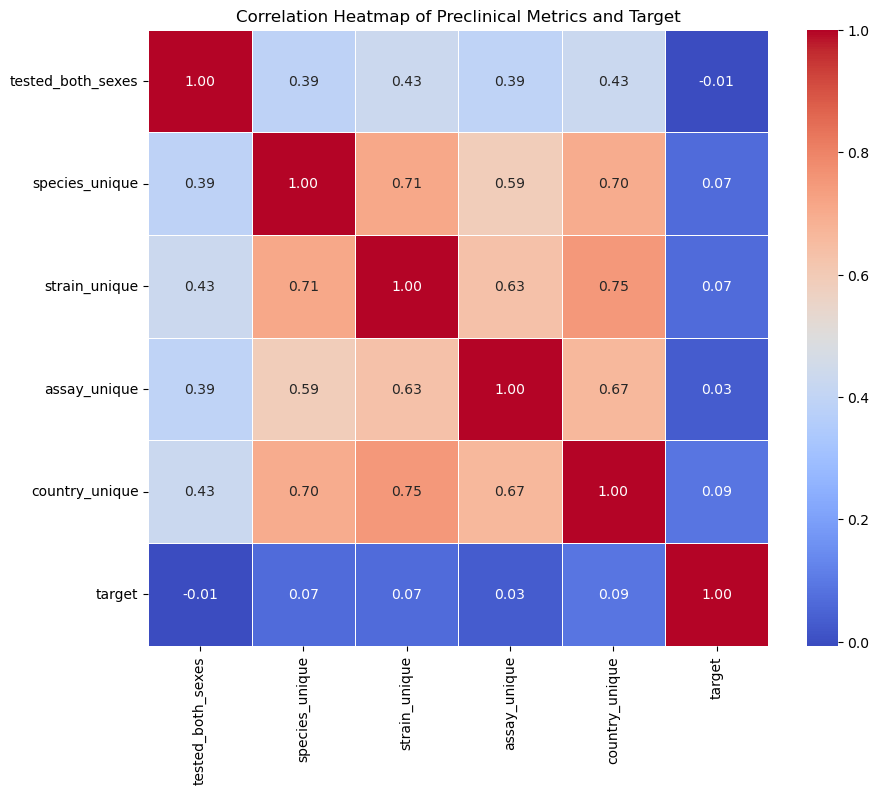

In [62]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Preclinical Metrics and Target')
plt.show()

In [43]:
from sklearn.linear_model import LogisticRegression # does it use regularization/ penalty by default? -> should be without penalization
from sklearn.preprocessing import StandardScaler # better without this -> bad for the binary variable, std dev of binary variable does not make sense
df = all_entities.copy()
# Prepare data
X = df[['species_unique', 'strain_unique', 'assay_unique', 'tested_both_sexes']]
y = df['target']

# Standardize (important for comparing coefficients)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit model
model = LogisticRegression()
model.fit(X_scaled, y)

# View importance
importance = pd.Series(model.coef_[0], index=X.columns)
print("Feature Importance (Log-Odds):")
print(importance.sort_values(ascending=False))

Feature Importance (Log-Odds):
species_unique       0.205871
strain_unique        0.000613
assay_unique        -0.016262
tested_both_sexes   -0.087504
dtype: float64


In [44]:
from sklearn.linear_model import LogisticRegression # does it use regularization/ penalty by default? -> should be without penalization
from sklearn.preprocessing import StandardScaler # better without this -> bad for the binary variable, std dev of binary variable does not make sense
# exp = odds ratio when i increase species by one
# idea: table with p-values and confidence intervals -> summary of the GLM fit -> 
# model selection -> cross validation
# missing data -> is it systematic? if it is related to a variable that has been collected it could be imputed -> try to omit missing ones
# forest plot for the coeff -> estimates + confidence interval (p-value); also case with multilpe imputations -> sensitivity analysis -> MICE package in R -> only if NOT "missing not at random"
# dorest plot at loggs ratio scale-> what increases/ decreases success -> conf interval!!
# check forest plot packages in R -> point estimate, conf interval, variable names -> give GLM object, get forest 

df = all_entities.copy()
# Prepare data
X = df[['species_unique', 'strain_unique', 'assay_unique', 'tested_both_sexes']]
y = df['target']

# Standardize (important for comparing coefficients)
scaler = StandardScaler()
X_scaled = X.copy()

# Fit model
model = LogisticRegression()
model.fit(X_scaled, y)

# View importance
importance = pd.Series(model.coef_[0], index=X.columns)
print("Feature Importance (Log-Odds):")
print(importance.sort_values(ascending=False))

Feature Importance (Log-Odds):
species_unique       0.186917
strain_unique        0.000126
assay_unique        -0.011778
tested_both_sexes   -0.177179
dtype: float64


In [49]:
from sklearn.linear_model import LogisticRegression # does it use regularization/ penalty by default? -> should be without penalization

df = all_entities.copy()
# Prepare data
X = df[['species_unique', 'strain_unique', 'assay_unique', 'tested_both_sexes']]
y = df['target']

X_scaled = X.copy()

# Fit model
model = LogisticRegression(
    penalty="none",
    solver="lbfgs",
    max_iter=1000
)
model.fit(X_scaled, y)

# View importance
importance = pd.Series(model.coef_[0], index=X.columns)
print("Feature Importance (Log-Odds):")
print(importance.sort_values(ascending=False))

Feature Importance (Log-Odds):
species_unique       0.187230
strain_unique        0.000109
assay_unique        -0.011786
tested_both_sexes   -0.177977
dtype: float64


/home/sdonev/data/conda/envs/torch-huggingface/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1182: FutureWarning: `penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour, set `penalty=None`.
  warnings.warn(


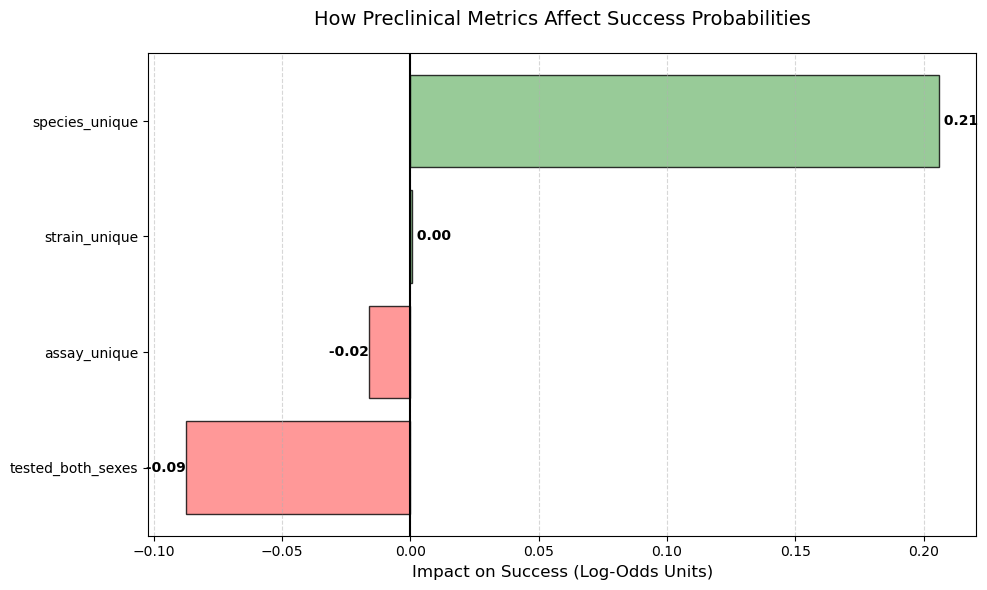

In [45]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Prepare the data
data = {
    'Feature': ['species_unique', 'strain_unique', 'assay_unique', 'tested_both_sexes'],
    'Log-Odds': [0.205871, 0.000613, -0.016262, -0.087504]
}

df_importance = pd.DataFrame(data).sort_values(by='Log-Odds', ascending=True)

# 2. Create the plot
plt.figure(figsize=(10, 6))
# Use green for positive impact and red for negative
colors = ['#ff7f7f' if x < 0 else '#7fbf7f' for x in df_importance['Log-Odds']]
bars = plt.barh(df_importance['Feature'], df_importance['Log-Odds'], color=colors, edgecolor='black', alpha=0.8)

# 3. Add styling
plt.axvline(x=0, color='black', linestyle='-', linewidth=1.5) # Reference line at 0
plt.xlabel('Impact on Success (Log-Odds Units)', fontsize=12)
plt.title('How Preclinical Metrics Affect Success Probabilities', fontsize=14, pad=20)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# 4. Label the bars with the actual values
for bar in bars:
    width = bar.get_width()
    label_x_pos = width if width > 0 else width
    plt.text(label_x_pos, bar.get_y() + bar.get_height()/2, f' {width:.2f}', 
             va='center', ha='left' if width > 0 else 'right', fontweight='bold')

plt.tight_layout()
plt.savefig('feature_importance_plot.png')

## Sample data for validation

In [39]:
sampled_df = pd.concat([
    all_entities[all_entities["target"] == 1].sample(n=5, random_state=42),
    all_entities[all_entities["target"] == 0].sample(n=5, random_state=42)
])
sampled_df

,drug_name,tested_both_sexes,species_unique,species_ge2,strain_unique,strains_ge2,assay_unique,assays_ge2,country_unique,countries_ge2,target
3374,cataract <> dexamethasone,1,2,1,2,1,3,1,3,1,1
4716,post-traumatic stress disorder <> minocycline,0,2,1,1,0,3,1,2,1,1
3314,brain hypoxia - ischemia <> sevoflurane,1,2,1,2,1,4,1,3,1,1
4071,kidney disorder <> warfarin,0,2,1,2,1,3,1,1,0,1
3297,bone <> vitamin d,0,1,0,0,0,1,0,1,0,1
565,cancer <> valproate,0,1,0,4,1,3,1,3,1,0
1220,headache disorder <> dexamethasone,1,1,0,1,0,2,1,1,0,0
1677,multiple <> bortezomib,0,1,0,2,1,2,1,1,0,0
1577,malaria <> erythropoietin,0,1,0,1,0,1,0,1,0,0
2834,toxic encephalopathy <> cisplatin,1,1,0,2,1,3,1,2,1,0


In [40]:
numeric_cols = [
    "tested_both_sexes",
    "species_unique",
    "strain_unique",
    "assay_unique",
    "country_unique",
]

# compute z-scores
z_scores = (
    all_entities[numeric_cols]
    .apply(lambda x: (x - x.mean()) / x.std())
    .abs()
)

# mark outliers (any column with z > 2.5)
outliers = all_entities[z_scores.max(axis=1) > 2.5]

outlier_sample = outliers.sample(n=5, random_state=42)
outlier_sample

,drug_name,tested_both_sexes,species_unique,species_ge2,strain_unique,strains_ge2,assay_unique,assays_ge2,country_unique,countries_ge2,target
3769,epilepsy <> phenytoin,1,8,1,48,1,5,1,25,1,1
141,alzheimer disease <> insulin,1,3,1,22,1,5,1,23,1,0
3098,anxiety disorder <> benzodiazepine,1,4,1,17,1,5,1,15,1,1
3820,focal epilepsy <> carbamazepine,1,5,1,6,1,4,1,9,1,1
3117,anxiety disorder <> melatonin,0,2,1,11,1,4,1,14,1,1


In [43]:
combined_preclin_df.head()

,normalized_key,PMID,title,disease_term_mondo_norm,drug_term_umls_norm,rigor_blinding,rigor_randomization,rigor_welfare,sample_size,animal_species,...,animal_number,assay_type,first_author_country,merged_mondo_label,merged_umls_label,study_classification,rigor_blinding_binary,rigor_randomization_binary,rigor_welfare_binary,sample_size_binary
0,drug dependence <> cocaine,21790900,Addictive potential of modafinil and cross-sen...,narcolepsy|cocaine dependence,Cocaine|modafinil,blinding-not-reported,randomization-present,welfare-present,sample-size-not-reported,mouse,...,"[22.0, 50.0, 52.0, 24.0]","Behavioral, Molecular & Cellular",Brazil,narcolepsy|cocaine dependence|drug dependence,Cocaine|modafinil,failed,0,1,1,0
1,cocaine dependence <> cocaine,21790900,Addictive potential of modafinil and cross-sen...,narcolepsy|cocaine dependence,Cocaine|modafinil,blinding-not-reported,randomization-present,welfare-present,sample-size-not-reported,mouse,...,"[22.0, 50.0, 52.0, 24.0]","Behavioral, Molecular & Cellular",Brazil,narcolepsy|cocaine dependence|drug dependence,Cocaine|modafinil,failed,0,1,1,0
2,drug dependence <> modafinil,21790900,Addictive potential of modafinil and cross-sen...,narcolepsy|cocaine dependence,Cocaine|modafinil,blinding-not-reported,randomization-present,welfare-present,sample-size-not-reported,mouse,...,"[22.0, 50.0, 52.0, 24.0]","Behavioral, Molecular & Cellular",Brazil,narcolepsy|cocaine dependence|drug dependence,Cocaine|modafinil,failed,0,1,1,0
3,cocaine dependence <> modafinil,21790900,Addictive potential of modafinil and cross-sen...,narcolepsy|cocaine dependence,Cocaine|modafinil,blinding-not-reported,randomization-present,welfare-present,sample-size-not-reported,mouse,...,"[22.0, 50.0, 52.0, 24.0]","Behavioral, Molecular & Cellular",Brazil,narcolepsy|cocaine dependence|drug dependence,Cocaine|modafinil,failed,0,1,1,0
4,drug dependence <> cocaine,29227643,Structure-Activity Relationship Studies on a S...,cocaine dependence,atypical dopamine transporter (dat) inhibitors...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,"mouse, rat",...,not reported,Molecular & Cellular,USA,cocaine dependence|drug dependence,3α-[bis (4-fluorophenyl) methoxy] tropanes|dat...,failed,0,0,0,0


In [42]:
sampled_and_outliers_df = pd.concat([
    sampled_df,
    outlier_sample
])
sampled_and_outliers_df

,drug_name,tested_both_sexes,species_unique,species_ge2,strain_unique,strains_ge2,assay_unique,assays_ge2,country_unique,countries_ge2,target
3374,cataract <> dexamethasone,1,2,1,2,1,3,1,3,1,1
4716,post-traumatic stress disorder <> minocycline,0,2,1,1,0,3,1,2,1,1
3314,brain hypoxia - ischemia <> sevoflurane,1,2,1,2,1,4,1,3,1,1
4071,kidney disorder <> warfarin,0,2,1,2,1,3,1,1,0,1
3297,bone <> vitamin d,0,1,0,0,0,1,0,1,0,1
565,cancer <> valproate,0,1,0,4,1,3,1,3,1,0
1220,headache disorder <> dexamethasone,1,1,0,1,0,2,1,1,0,0
1677,multiple <> bortezomib,0,1,0,2,1,2,1,1,0,0
1577,malaria <> erythropoietin,0,1,0,1,0,1,0,1,0,0
2834,toxic encephalopathy <> cisplatin,1,1,0,2,1,3,1,2,1,0


In [48]:
out_dir="./data/translation_validation"
def safe_filename(s: str) -> str:
    s = s.strip()
    s = re.sub(r"[^\w\-<> ]+", "", s)
    s = s.replace(" <> ", "_")
    s = re.sub(r"\s+", "_", s)
    return s[:200]

# df_drugs must contain: drug_name, target
for _, row in (
    sampled_and_outliers_df[["drug_name", "target"]]
    .dropna()
    .drop_duplicates()
    .iterrows()
):
    key = row["drug_name"]
    target = int(row["target"])

    prefix = "positive_" if target == 1 else "negative_"

    sub = combined_preclin_df[
        combined_preclin_df["normalized_key"] == key
    ].copy()

    if sub.empty:
        continue
        

    if len(sub) > 5:
        sub = sub.sample(n=5, random_state=42)
        
    fname = prefix + safe_filename(key) + ".csv"
    path = os.path.join(out_dir, fname)

    sub.to_csv(path, index=False)

print(f"Saved per-drug CSVs with target prefix to: {out_dir}")

Saved per-drug CSVs with target prefix to: ./data/translation_validation


In [50]:
sampled_and_outliers_df.to_csv(out_dir+"/sampled_and_outliers_df.csv",index=False)

In [52]:
 combined_preclin_df[
        combined_preclin_df["normalized_key"] == "epilepsy <> phenytoin"
    ].to_csv(out_dir +"/epilepsy_phenytoin_all.csv",index=False)

In [69]:
combined_preclin_df[
    (combined_preclin_df["normalized_key"] == "focal epilepsy <> carbamazepine") &
    (combined_preclin_df["animal_species"].str.contains("dog"))
]


,normalized_key,PMID,title,disease_term_mondo_norm,drug_term_umls_norm,rigor_blinding,rigor_randomization,rigor_welfare,sample_size,animal_species,...,animal_number,assay_type,first_author_country,merged_mondo_label,merged_umls_label,study_classification,rigor_blinding_binary,rigor_randomization_binary,rigor_welfare_binary,sample_size_binary


In [72]:
combined_preclin_df[
    (combined_preclin_df["normalized_key"] == "focal epilepsy <> carbamazepine")
].animal_species

19702       guinea pig
20333            mouse
20945              rat
21419              rat
21477              rat
21945              rat
22034              rat
22047       mouse, rat
22169            mouse
22177              rat
24222              rat
24225            mouse
24692           rabbit
24693              rat
24695      pig, rabbit
24696    species-other
24697              pig
Name: animal_species, dtype: object

In [39]:
combined_preclin_df[combined_preclin_df['PMID']==24878681]

,normalized_key,PMID,title,disease_term_mondo_norm,drug_term_umls_norm,rigor_blinding,rigor_randomization,rigor_welfare,sample_size,animal_species,animal_sex,animal_age,animal_strain,animal_number,assay_type,first_author_country,merged_mondo_label,merged_umls_label,study_classification
31101,brain ischemia <> sevoflurane,24878681,A combination of mild hypothermia and sevoflur...,brain hypoxia - ischemia|brain|perinatal asphyxia,sevoflurane,blinding-not-reported,randomization-present,welfare-not-reported,sample-size-not-reported,mouse,not-reported,not reported,not reported,"[19.0, 22.0, 29.0]","Behavioral, Histology, Molecular & Cellular, P...",USA,brain hypoxia - ischemia|brain|perinatal asphy...,sevoflurane,approved
31102,brain hypoxia - ischemia <> sevoflurane,24878681,A combination of mild hypothermia and sevoflur...,brain hypoxia - ischemia|brain|perinatal asphyxia,sevoflurane,blinding-not-reported,randomization-present,welfare-not-reported,sample-size-not-reported,mouse,not-reported,not reported,not reported,"[19.0, 22.0, 29.0]","Behavioral, Histology, Molecular & Cellular, P...",USA,brain hypoxia - ischemia|brain|perinatal asphy...,sevoflurane,approved


In [2]:
df = pd.read_json(
    "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/07_full_text_retrieval/materials_methods/combined/combined_materials_methods.jsonl",
    lines=True
)

In [13]:
print(df.loc[df["PMID"] == "24878681", "Text"].iloc[0])


Adult Body Weight
To assess general health and nutritional status, adult animals from all 3 experimental groups were weighed before the administration of apomorphine.

Adult Muscle Control
The pharmacological challenge with apomorphine was the final test performed to assess the effects of protective strategies during neonatal HI on basal ganglia integrity in adulthood. Apomorphine, a dopaminergic agonist, greatly enhances ipsilateral rotations in rodents with unilateral striatal injury, such as created in the present model. Animals baseline spontaneous circling behaviors were quantified for 10 minutes in the open-field as described above, followed by intraperitoneal injection of 1.2 mg/kg apomorphine and a repeat test session.

Arterial Blood Gas and Glucose
To obtain blood chemistry data, P10 mouse pups (n= 22) were exposed to Room Air (n= 7), HI (n= 8), or HI-Protect (n= 7), as described above. In the Room Air group, after 60 minutes of fasting, pups were briefly anesthetized before 